In [1]:
import pandas as pd

file = "mobile_shoppee_curation_project.xlsx"

sheet_names = pd.ExcelFile(file).sheet_names
print(sheet_names)

['Customers', 'MobileModels', 'ShopLocations', 'Sales', 'Stocks', 'Offers', 'DataDictionary']


In [2]:
import pandas as pd
sales = pd.read_csv(r"C:\Users\TANU\Documents\EDA/Sales.csv")
models = pd.read_csv(r"C:\Users\TANU\Documents\EDA/MobileModels.csv")

In [3]:
#Decision Tree

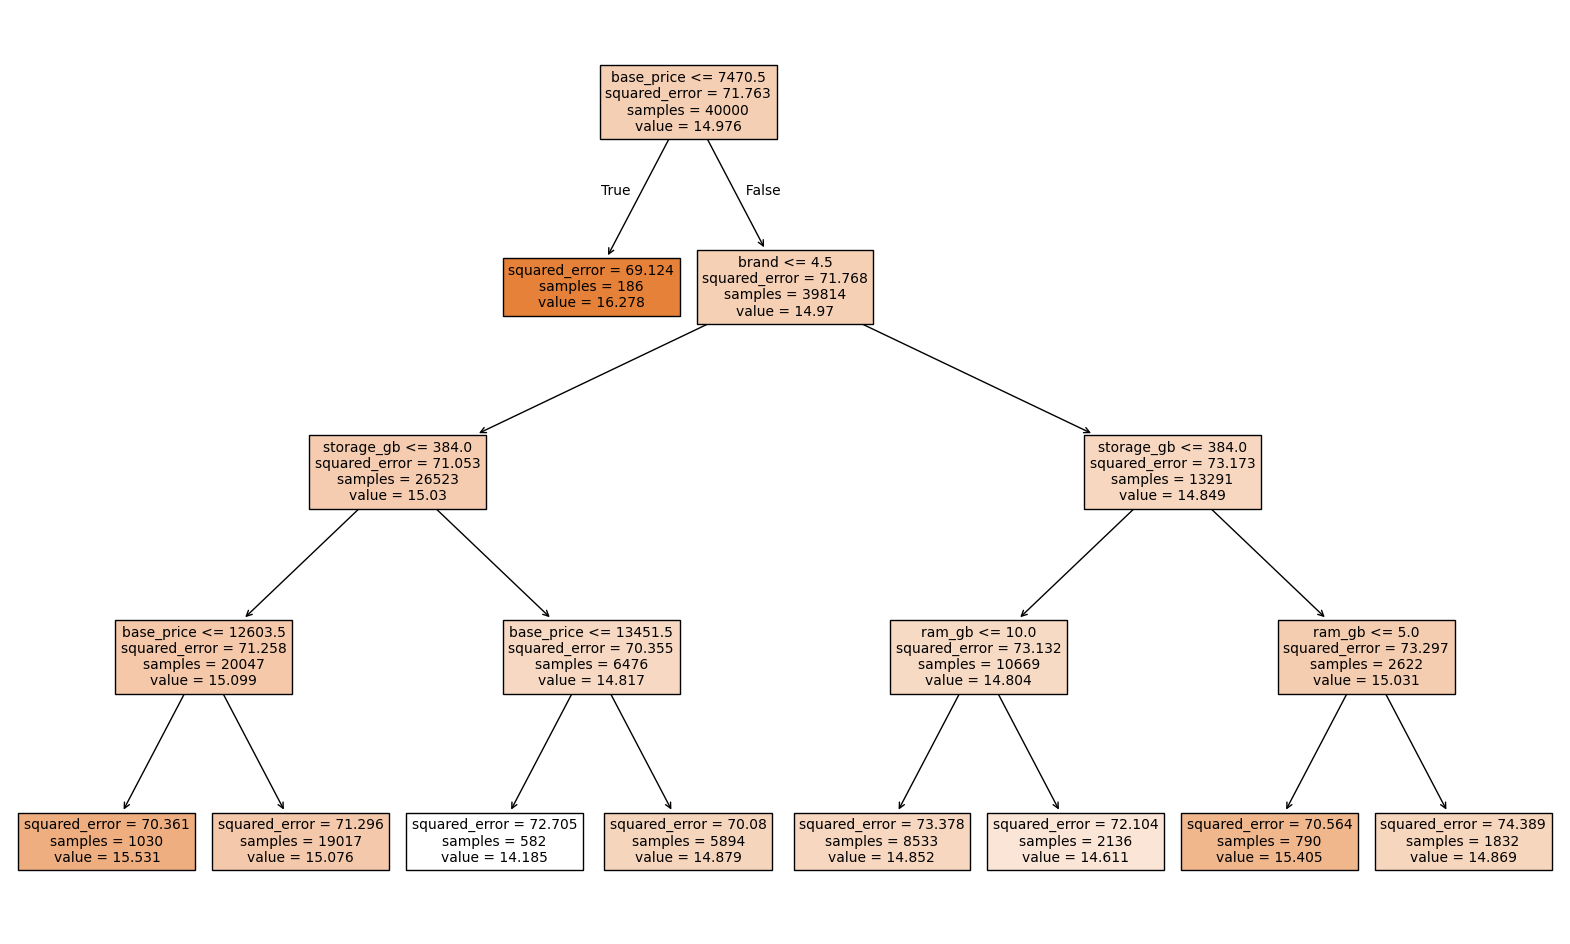

In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 1. Load dataset
sales_fp  = r"C:\Users\TANU\Documents\EDA\Sales.csv"

df = pd.read_csv(sales_fp)

# 2. Select required columns
# We only need brand, ram, storage, base_price → to predict discount
needed_cols = ["brand", "ram_gb", "storage_gb", "base_price", "discount"]

df = df[needed_cols].dropna()

# 3. Encode brand (string → number)
le = LabelEncoder()
df["brand_encoded"] = le.fit_transform(df["brand"])

# 4. Features & Target
X = df[["brand_encoded", "ram_gb", "storage_gb", "base_price"]]
y = df["discount"]

# 5. Train Decision Tree
model = DecisionTreeRegressor(max_depth=4)
model.fit(X, y)

# 6. Plot Decision Tree
plt.figure(figsize=(20,12))
plot_tree(
    model,
    feature_names=["brand", "ram_gb", "storage_gb", "base_price"],
    filled=True,
    fontsize=10
)
plt.show()


In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
import ipywidgets as widgets
from IPython.display import display

# 1. Load Sales.csv
sales_fp = r"C:\Users\TANU\Documents\EDA\Sales.csv"
df = pd.read_csv(sales_fp)

# Keep required columns
df = df[["brand", "ram_gb", "storage_gb", "base_price", "discount"]].dropna()

# 2. Encode brand
brand_encoder = LabelEncoder()
df["brand_enc"] = brand_encoder.fit_transform(df["brand"])

X = df[["brand_enc", "ram_gb", "storage_gb", "base_price"]]
y = df["discount"]

# Train model
model = DecisionTreeRegressor(max_depth=6)
model.fit(X, y)

print("✔ Model trained successfully!")

# 3. DROPDOWN WIDGETS

brand_dropdown = widgets.Dropdown(
    options=sorted(df["brand"].unique()),
    description='Brand:',
    value=sorted(df["brand"].unique())[0]
)

ram_dropdown = widgets.Dropdown(
    options=sorted(df["ram_gb"].unique()),
    description='RAM (GB):'
)

storage_dropdown = widgets.Dropdown(
    options=sorted(df["storage_gb"].unique()),
    description='Storage (GB):'
)

price_box = widgets.FloatText(
    description='Base Price:'
)

predict_btn = widgets.Button(
    description="Predict Discount",
    button_style='success'
)

output = widgets.Output()

# 4. PREDICTION FUNCTION
def predict_discount(b):
    output.clear_output()

    brand = brand_dropdown.value
    ram = ram_dropdown.value
    storage = storage_dropdown.value
    price = price_box.value

    # Encode brand
    brand_enc = brand_encoder.transform([brand])[0]

    # Predict
    x_new = [[brand_enc, ram, storage, price]]
    pred = model.predict(x_new)[0]

    with output:
        print(f"📌 Predicted Discount = {pred:.2f}%")

predict_btn.on_click(predict_discount)

# Show UI
display(brand_dropdown, ram_dropdown, storage_dropdown, price_box, predict_btn, output)


✔ Model trained successfully!


Dropdown(description='Brand:', options=('Apple', 'Motorola', 'OPPO', 'OnePlus', 'Samsung', 'Xiaomi', 'realme',…

Dropdown(description='RAM (GB):', options=(np.int64(4), np.int64(6), np.int64(8), np.int64(12)), value=np.int6…

Dropdown(description='Storage (GB):', options=(np.int64(64), np.int64(128), np.int64(256), np.int64(512)), val…

FloatText(value=0.0, description='Base Price:')

Button(button_style='success', description='Predict Discount', style=ButtonStyle())

Output()